In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from waymo_agent import *

In [3]:
G_raw = ox.graph_from_place(
    "Manhattan, New York, USA",
    network_type="drive",
    simplify=True,
)
fig, ax = plt.subplots(figsize=(8, 8))
plt.close(fig)
# 2. Plot it to verify (Manhattan is dense, so this might take a moment)
fig, ax = ox.plot_graph(
    G_raw,
    node_size=0,
    edge_linewidth=0.5,
    ax=ax,
    close=True,
    save=True,
    filepath=IMG_DIR / MANHATTAN_BASIC,
    dpi=1_000,
)

print(f"Nodes: {G_raw.number_of_nodes()}")
print(f"Edges: {G_raw.number_of_edges()}")

Nodes: 4619
Edges: 9901


## Basic Save / Load

In [4]:
MAP_DIR

PosixPath('/Users/Akseldkw/coding/Columbia/RL-Project/maps')

In [12]:
# ox.save_graphml(G_raw, filepath=MAP_DIR / MANHATTAN_RAW_GRAPH)

In [13]:
G_out = ox.load_graphml(filepath=MAP_DIR / MANHATTAN_RAW_GRAPH)

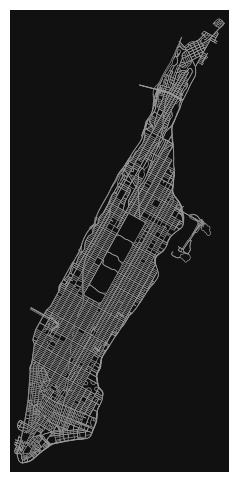

In [14]:
fig, ax = ox.plot_graph(G_out, node_size=0, edge_linewidth=0.5, figsize=(6, 6))

## Preprocess Graph

In [15]:
G = preprocess_graph(G_raw)

In [16]:
from waymo_agent.osmnx.inspect import inspect_graph, max_speed_distribution, plot_maxspeed

In [17]:
inspect_graph(G)

Graph has 4619 nodes and 9901 edges.
Sample node attributes: {'y': 40.7564802, 'x': -73.997767, 'highway': 'traffic_signals', 'street_count': 4}

Sample edge attributes: {'osmid': 68518745, 'highway': 'secondary', 'lanes': '1', 'name': 'Riverside Drive', 'oneway': True, 'reversed': False, 'length': np.float64(12.306542229590399)}


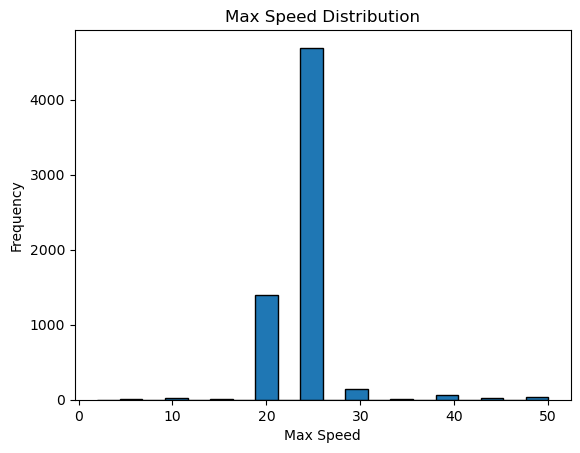

In [18]:
plot_maxspeed(G)

In [19]:
# ox.save_graphml(G, filepath=MAP_DIR / MANHATTAN_PROCESSED_GRAPH)